stars


=== PTT Stock 看板情緒分析結果 ===

研究問題：
1. 川普關稅宣布與暫緩宣布前後，標題、內文、推文的星級是否有顯著差異？
2. 關稅宣布後情緒是否偏負面？暫緩宣布後是否轉為正面？

時間區段：
- 前宣布期：2025年3月27日–4月2日
- 核心期：2025年4月3日–4月9日（4月3日關稅宣布，4月9日暫緩宣布）
- 後續期：2025年4月10日–4月16日

平均星級：
        title_star  content_star  push_star
period                                     
前宣布期      2.188455      1.131034   1.310580
核心期       1.836181      1.094166   1.190428
後續期       1.837567      1.102344   1.186533

ANOVA 分析結果：

title_star:
F 統計量: 14.2319
P 值: 0.0000

content_star:
F 統計量: 1.5441
P 值: 0.2136

push_star:
F 統計量: 5.2908
P 值: 0.0051

T-Test 分析結果：

title_star:
前宣布期 vs 核心期: T=4.7290, P=0.0000
核心期 vs 後續期: T=-0.0270, P=0.9785

content_star:
前宣布期 vs 核心期: T=1.6215, P=0.1053
核心期 vs 後續期: T=-0.5209, P=0.6025

push_star:
前宣布期 vs 核心期: T=2.6109, P=0.0092
核心期 vs 後續期: T=0.1373, P=0.8908

時間序列圖：


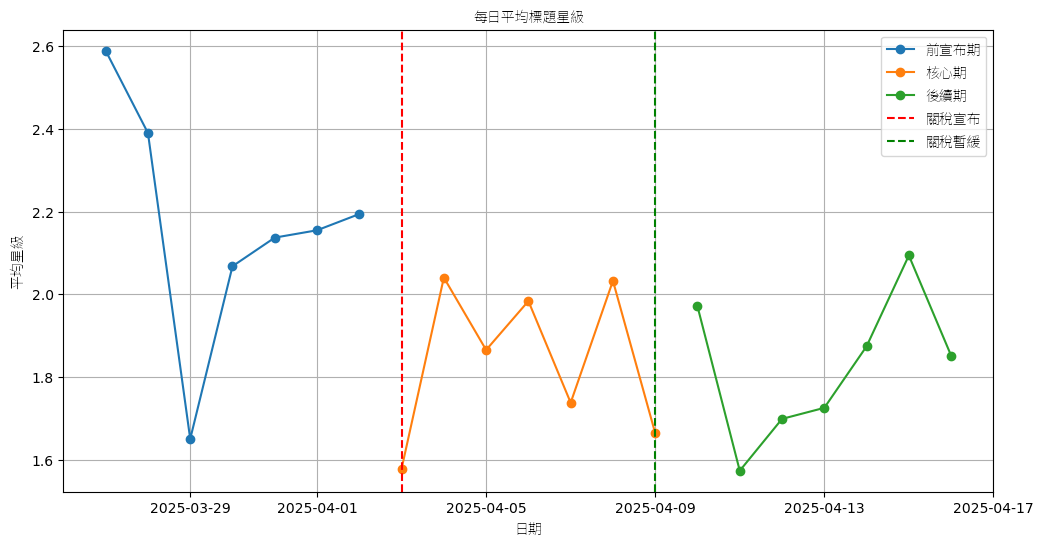

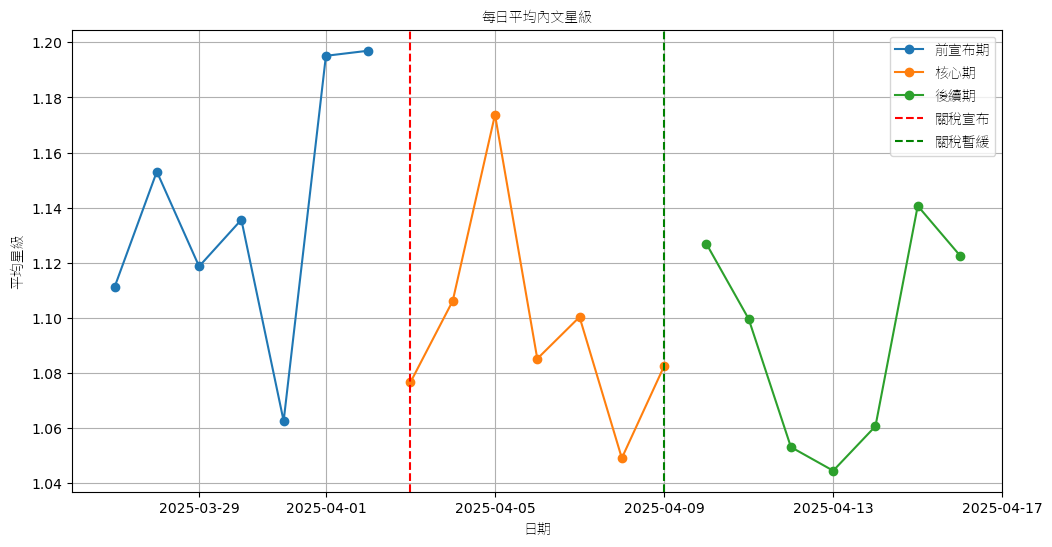

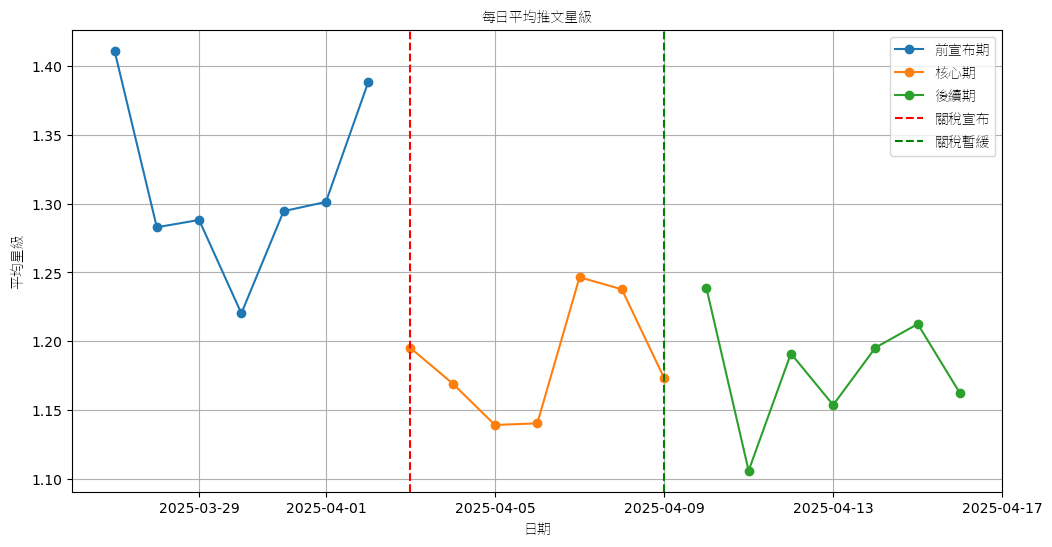

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import f_oneway, ttest_ind
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging
import sys
import os

# Logging 設定
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    filename='sentiment_analysis.log',
    filemode='w',
    encoding='utf-8'
)
logging.info("情緒分析開始")

# 字體設定
def set_font():
    try:
        font_path = 'Noto_Sans_TC.ttf'
        if not os.path.exists(font_path):
            print("警告：找不到字體檔案 Noto_Sans_TC.ttf，使用預設字體。")
            return None
        font = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font.get_name()
        plt.rcParams['axes.unicode_minus'] = False
        return font
    except Exception as e:
        print(f"字體設定失敗：{e}")
        return None

# 資料庫連線
def get_sqlite_connection(db_path="ptt_data.db"):
    try:
        conn = sqlite3.connect(db_path)
        return conn
    except Exception as e:
        print(f"資料庫連線失敗：{e}")
        sys.exit(1)

# 查詢資料
def fetch_data(conn, start_date, end_date):
    q_articles = """
    SELECT id, timestamp, title_star_label, content_star_label
    FROM sentiments
    WHERE board = 'Stock' AND timestamp BETWEEN ? AND ?
    """
    q_pushes = """
    SELECT article_id, push_star_label
    FROM push_comments
    WHERE article_id IN (
        SELECT id FROM sentiments
        WHERE board = 'Stock' AND timestamp BETWEEN ? AND ?
    )
    """
    try:
        articles = pd.read_sql_query(q_articles, conn, params=(start_date, end_date))
        pushes = pd.read_sql_query(q_pushes, conn, params=(start_date, end_date))
        return articles, pushes
    except Exception as e:
        print(f"查詢資料失敗：{e}")
        return None, None

# 時間區段分配
def assign_period(ts):
    date = datetime.fromisoformat(ts.replace('Z', '+00:00')).date()
    if date <= datetime(2025, 4, 2).date():
        return '前宣布期'
    elif date <= datetime(2025, 4, 9).date():
        return '核心期'
    else:
        return '後續期'

# 星等轉換
def to_star_number(x):
    try:
        if isinstance(x, str) and 'star' in x:
            return int(x.split()[0])
    except:
        pass
    return np.nan

# 統計分析
def perform_anova(df, column, periods):
    groups = [df[df['period'] == p][column].dropna() for p in periods]
    if not all(len(g) > 0 for g in groups):
        return float('nan'), float('nan')
    return f_oneway(*groups)

def perform_ttest(df, column, p1, p2):
    g1 = df[df['period'] == p1][column].dropna()
    g2 = df[df['period'] == p2][column].dropna()
    if len(g1) == 0 or len(g2) == 0:
        return float('nan'), float('nan')
    return ttest_ind(g1, g2, equal_var=False)

# 時間序列圖
def plot_timeseries(df, column, title, font):
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    daily_avg = df.groupby(['date', 'period'])[column].mean().reset_index()
    plt.figure(figsize=(12, 6))
    for period in daily_avg['period'].unique():
        subset = daily_avg[daily_avg['period'] == period]
        plt.plot(subset['date'], subset[column], marker='o', label=period)
    plt.axvline(datetime(2025, 4, 3).date(), color='r', linestyle='--', label='關稅宣布')
    plt.axvline(datetime(2025, 4, 9).date(), color='g', linestyle='--', label='關稅暫緩')
    plt.title(title, fontproperties=font)
    plt.xlabel('日期', fontproperties=font)
    plt.ylabel('平均星級', fontproperties=font)
    plt.legend(prop=font)
    plt.grid(True)
    plt.show()

# 主程式
def main():
    font = set_font()
    start_date = '2025-03-27T00:00:00'
    end_date = '2025-04-16T23:59:59'
    conn = get_sqlite_connection()
    articles, pushes = fetch_data(conn, start_date, end_date)

    if articles is None or pushes is None or articles.empty:
        print("無效或空資料，程序中止。")
        return

    push_mode = pushes.groupby('article_id')['push_star_label'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()
    articles = articles.merge(push_mode, left_on='id', right_on='article_id', how='left')

    articles['period'] = articles['timestamp'].apply(assign_period)
    articles['title_star'] = articles['title_star_label'].apply(to_star_number)
    articles['content_star'] = articles['content_star_label'].apply(to_star_number)
    articles['push_star'] = articles['push_star_label'].apply(to_star_number)
    articles = articles.dropna(subset=['title_star', 'content_star', 'push_star'], how='all')

    periods = ['前宣布期', '核心期', '後續期']
    summary = articles.groupby('period')[['title_star', 'content_star', 'push_star']].mean().reindex(periods)
    print("\n=== PTT Stock 看板情緒分析結果 ===")
    print("\n研究問題：")
    print("1. 川普關稅宣布與暫緩宣布前後，標題、內文、推文的星級是否有顯著差異？")
    print("2. 關稅宣布後情緒是否偏負面？暫緩宣布後是否轉為正面？")

    print("\n時間區段：")
    print("- 前宣布期：2025年3月27日–4月2日")
    print("- 核心期：2025年4月3日–4月9日（4月3日關稅宣布，4月9日暫緩宣布）")
    print("- 後續期：2025年4月10日–4月16日")

    print("\n平均星級：")
    print(summary)

    print("\nANOVA 分析結果：")
    for col in ['title_star', 'content_star', 'push_star']:
        f, p = perform_anova(articles, col, periods)
        print(f"\n{col}:")
        print(f"F 統計量: {f:.4f}" if not pd.isna(f) else "F 統計量: N/A")
        print(f"P 值: {p:.4f}" if not pd.isna(p) else "P 值: N/A")

    print("\nT-Test 分析結果：")
    for col in ['title_star', 'content_star', 'push_star']:
        t1, p1 = perform_ttest(articles, col, '前宣布期', '核心期')
        t2, p2 = perform_ttest(articles, col, '核心期', '後續期')
        print(f"\n{col}:")
        print(f"前宣布期 vs 核心期: T={t1:.4f}, P={p1:.4f}" if not pd.isna(t1) else "前宣布期 vs 核心期: N/A")
        print(f"核心期 vs 後續期: T={t2:.4f}, P={p2:.4f}" if not pd.isna(t2) else "核心期 vs 後續期: N/A")

    print("\n時間序列圖：")
    plot_timeseries(articles, 'title_star', '每日平均標題星級', font)
    plot_timeseries(articles, 'content_star', '每日平均內文星級', font)
    plot_timeseries(articles, 'push_star', '每日平均推文星級', font)

    conn.close()

if __name__ == '__main__':
    main()

只計算score>0.4以上的


=== PTT Stock 看板情緒分析結果 ===

研究問題：
1. 川普關稅宣布與暫緩宣布前後，標題、內文、推文的星級是否有顯著差異？
2. 關稅宣布後情緒是否偏負面？暫緩宣布後是否轉為正面？

時間區段：
- 前宣布期：2025年3月27日–4月2日
- 核心期：2025年4月3日–4月9日（4月3日關稅宣布，4月9日暫緩宣布）
- 後續期：2025年4月10日–4月16日

平均星級：
        title_star  content_star  push_star
period                                     
前宣布期      2.009174      1.046296   1.310905
核心期       1.697433      1.048856   1.163037
後續期       1.688433      1.051838   1.187678

ANOVA 分析結果：

title_star:
F 統計量: 9.5271
P 值: 0.0001

content_star:
F 統計量: 0.0542
P 值: 0.9472

push_star:
F 統計量: 5.1870
P 值: 0.0056

T-Test 分析結果：

title_star:
前宣布期 vs 核心期: T=3.7522, P=0.0002
核心期 vs 後續期: T=0.1680, P=0.8666

content_star:
前宣布期 vs 核心期: T=-0.1501, P=0.8807
核心期 vs 後續期: T=-0.2447, P=0.8067

push_star:
前宣布期 vs 核心期: T=2.7092, P=0.0069
核心期 vs 後續期: T=-0.7586, P=0.4482

時間序列圖：


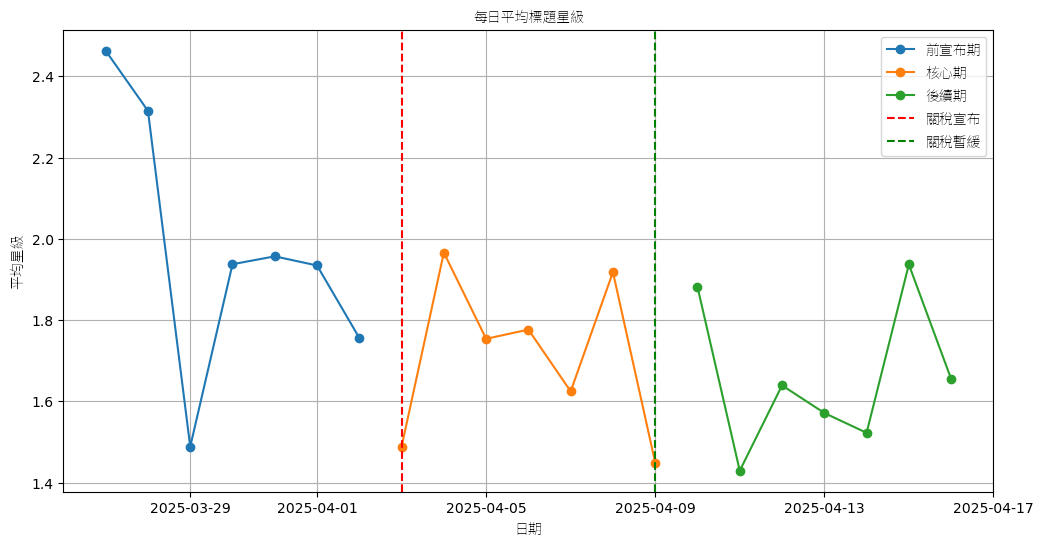

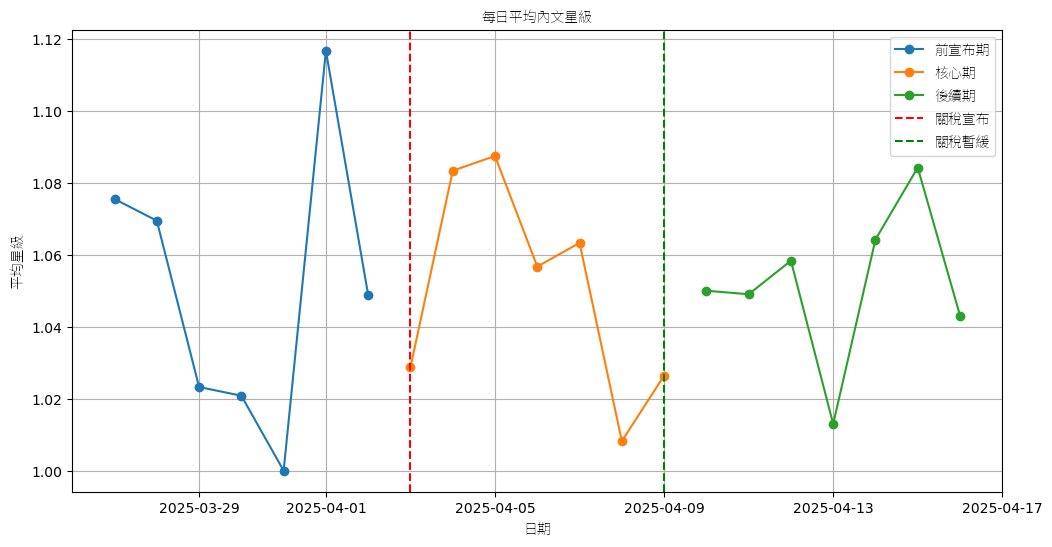

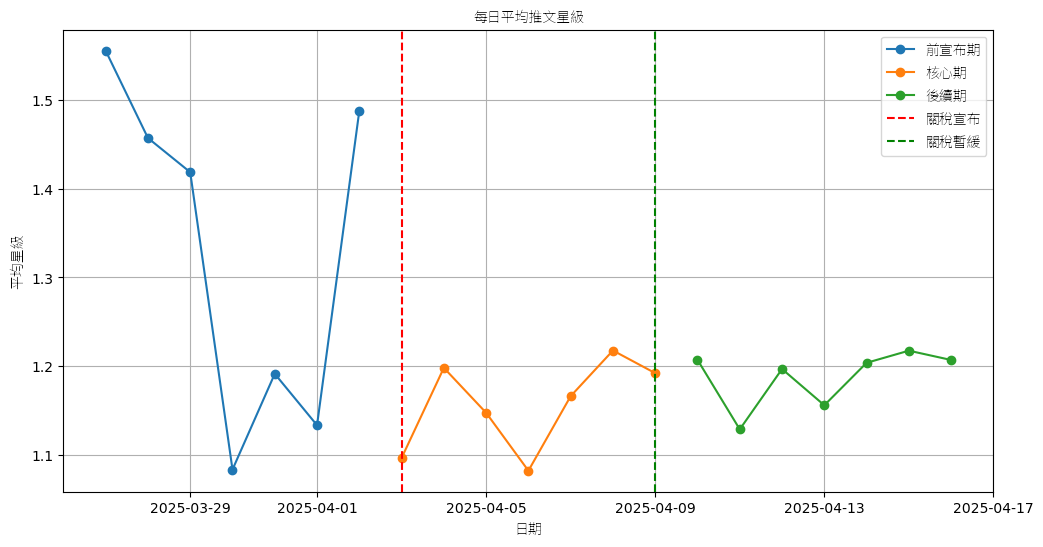

: 

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import f_oneway, ttest_ind
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging
import sys
import os

# Logging 設定
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    filename='sentiment_analysis.log',
    filemode='w',
    encoding='utf-8'
)
logging.info("情緒分析開始")

# 字體設定
def set_font():
    try:
        font_path = 'Noto_Sans_TC.ttf'
        if not os.path.exists(font_path):
            print("警告：找不到字體檔案 Noto_Sans_TC.ttf，使用預設字體。")
            return None
        font = fm.FontProperties(fname=font_path)
        plt.rcParams['font.family'] = font.get_name()
        plt.rcParams['axes.unicode_minus'] = False
        return font
    except Exception as e:
        print(f"字體設定失敗：{e}")
        return None

# 資料庫連線
def get_sqlite_connection(db_path="ptt_data.db"):
    try:
        conn = sqlite3.connect(db_path)
        return conn
    except Exception as e:
        print(f"資料庫連線失敗：{e}")
        sys.exit(1)

# 查詢資料
def fetch_data(conn, start_date, end_date):
    q_articles = """
    SELECT id, timestamp, title_star_label, content_star_label, title_score, content_score
    FROM sentiments
    WHERE board = 'Stock' AND timestamp BETWEEN ? AND ?
    """
    q_pushes = """
    SELECT article_id, push_star_label, push_score
    FROM push_comments
    WHERE article_id IN (
        SELECT id FROM sentiments
        WHERE board = 'Stock' AND timestamp BETWEEN ? AND ?
    )
    """
    try:
        articles = pd.read_sql_query(q_articles, conn, params=(start_date, end_date))
        pushes = pd.read_sql_query(q_pushes, conn, params=(start_date, end_date))
        return articles, pushes
    except Exception as e:
        print(f"查詢資料失敗：{e}")
        return None, None

# 時間區段分配
def assign_period(ts):
    date = datetime.fromisoformat(ts.replace('Z', '+00:00')).date()
    if date <= datetime(2025, 4, 2).date():
        return '前宣布期'
    elif date <= datetime(2025, 4, 9).date():
        return '核心期'
    else:
        return '後續期'

# 星等轉換
def to_star_number(x):
    try:
        if isinstance(x, str) and 'star' in x:
            return int(x.split()[0])
    except:
        pass
    return np.nan

# 統計分析
def perform_anova(df, column, periods):
    groups = [df[df['period'] == p][column].dropna() for p in periods]
    if not all(len(g) > 0 for g in groups):
        return float('nan'), float('nan')
    return f_oneway(*groups)

def perform_ttest(df, column, p1, p2):
    g1 = df[df['period'] == p1][column].dropna()
    g2 = df[df['period'] == p2][column].dropna()
    if len(g1) == 0 or len(g2) == 0:
        return float('nan'), float('nan')
    return ttest_ind(g1, g2, equal_var=False)

# 時間序列圖
def plot_timeseries(df, column, title, font):
    df['date'] = pd.to_datetime(df['timestamp']).dt.date
    daily_avg = df.groupby(['date', 'period'])[column].mean().reset_index()
    plt.figure(figsize=(12, 6))
    for period in daily_avg['period'].unique():
        subset = daily_avg[daily_avg['period'] == period]
        plt.plot(subset['date'], subset[column], marker='o', label=period)
    plt.axvline(datetime(2025, 4, 3).date(), color='r', linestyle='--', label='關稅宣布')
    plt.axvline(datetime(2025, 4, 9).date(), color='g', linestyle='--', label='關稅暫緩')
    plt.title(title, fontproperties=font)
    plt.xlabel('日期', fontproperties=font)
    plt.ylabel('平均星級', fontproperties=font)
    plt.legend(prop=font)
    plt.grid(True)
    plt.show()

# 主程式
def main():
    font = set_font()
    start_date = '2025-03-27T00:00:00'
    end_date = '2025-04-16T23:59:59'
    conn = get_sqlite_connection()
    articles, pushes = fetch_data(conn, start_date, end_date)

    if articles is None or pushes is None or articles.empty:
        print("無效或空資料，程序中止。")
        return

    # 篩選 score >= 0.4 的文章與推文
    articles = articles[(articles['title_score'] >= 0.4) | (articles['content_score'] >= 0.4)]
    pushes = pushes[pushes['push_score'] >= 0.4]

    push_mode = pushes.groupby('article_id')['push_star_label'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()
    articles = articles.merge(push_mode, left_on='id', right_on='article_id', how='left')

    articles['period'] = articles['timestamp'].apply(assign_period)
    articles['title_star'] = articles['title_star_label'].apply(to_star_number)
    articles['content_star'] = articles['content_star_label'].apply(to_star_number)
    articles['push_star'] = articles['push_star_label'].apply(to_star_number)
    articles = articles.dropna(subset=['title_star', 'content_star', 'push_star'], how='all')

    periods = ['前宣布期', '核心期', '後續期']
    summary = articles.groupby('period')[['title_star', 'content_star', 'push_star']].mean().reindex(periods)
    print("\n=== PTT Stock 看板情緒分析結果 ===")
    print("\n研究問題：")
    print("1. 川普關稅宣布與暫緩宣布前後，標題、內文、推文的星級是否有顯著差異？")
    print("2. 關稅宣布後情緒是否偏負面？暫緩宣布後是否轉為正面？")

    print("\n時間區段：")
    print("- 前宣布期：2025年3月27日–4月2日")
    print("- 核心期：2025年4月3日–4月9日（4月3日關稅宣布，4月9日暫緩宣布）")
    print("- 後續期：2025年4月10日–4月16日")

    print("\n平均星級：")
    print(summary)

    print("\nANOVA 分析結果：")
    for col in ['title_star', 'content_star', 'push_star']:
        f, p = perform_anova(articles, col, periods)
        print(f"\n{col}:")
        print(f"F 統計量: {f:.4f}" if not pd.isna(f) else "F 統計量: N/A")
        print(f"P 值: {p:.4f}" if not pd.isna(p) else "P 值: N/A")

    print("\nT-Test 分析結果：")
    for col in ['title_star', 'content_star', 'push_star']:
        t1, p1 = perform_ttest(articles, col, '前宣布期', '核心期')
        t2, p2 = perform_ttest(articles, col, '核心期', '後續期')
        print(f"\n{col}:")
        print(f"前宣布期 vs 核心期: T={t1:.4f}, P={p1:.4f}" if not pd.isna(t1) else "前宣布期 vs 核心期: N/A")
        print(f"核心期 vs 後續期: T={t2:.4f}, P={p2:.4f}" if not pd.isna(t2) else "核心期 vs 後續期: N/A")

    print("\n時間序列圖：")
    plot_timeseries(articles, 'title_star', '每日平均標題星級', font)
    plot_timeseries(articles, 'content_star', '每日平均內文星級', font)
    plot_timeseries(articles, 'push_star', '每日平均推文星級', font)

    conn.close()

if __name__ == '__main__':
    main()
